# DCF Valuation Model - Walkthrough

This notebook is a narrated tour of the `dcf` package. All logic lives in the
importable, tested modules under `dcf/`; here we only *drive* them and read the
output. The story has five acts:

1. Turn financial-statement inputs into a ten-year FCFF projection
2. Discount that stream to an **enterprise value**, two terminal-value ways
3. Sweep the assumptions into a **sensitivity grid** and heatmaps
4. Read the **divergence** between the two terminal methods - the real finding
5. Build the **FCFE** equity view and **reconcile** it against enterprise value

The model is deliberately transparent about where it is weak; see the final
section and the README.

## 1. Inputs -> a ten-year projection

You hand the model base-year dollar figures straight off the statements (revenue, EBIT, D&A, capex, net working capital), a tax rate, and a growth assumption. `Assumptions.from_base_year` derives the ratios; `build_projection` rolls them forward ten years, computing FCFF each year with the same tested `fcff()` function.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from dcf.projection import Assumptions, build_projection
from dcf.valuation import enterprise_value, cost_of_equity_capm, wacc
from dcf.sensitivity import ev_grid, divergence_grid
from dcf.plots import plot_ev_grid, plot_divergence_grid
from dcf.fcfe import reconcile_equity

a = Assumptions.from_base_year(
    revenue=1000, ebit=200, dna=50, capex=70, nwc=100,
    tax_rate=0.25, growth=0.10,
)
proj = build_projection(a)
proj.round(1)

,revenue,ebit,dna,capex,delta_nwc,fcff
year,,,,,,
1,1100.0,220.0,55.0,77.0,10.0,133.0
2,1210.0,242.0,60.5,84.7,11.0,146.3
3,1331.0,266.2,66.6,93.2,12.1,160.9
4,1464.1,292.8,73.2,102.5,13.3,177.0
5,1610.5,322.1,80.5,112.7,14.6,194.7
6,1771.6,354.3,88.6,124.0,16.1,214.2
7,1948.7,389.7,97.4,136.4,17.7,235.6
8,2143.6,428.7,107.2,150.1,19.5,259.2
9,2357.9,471.6,117.9,165.1,21.4,285.1


Every line is driven off revenue. Note `delta_nwc` grows with the *change* in revenue - a zero-growth year would tie up no new working capital. FCFF is `EBIT*(1-tax) + D&A - Capex - dNWC` each year.

## 2. Enterprise value, two terminal-value ways

Discount the FCFF stream at WACC and add a discounted **terminal value**. Gordon growth assumes a small perpetual growth rate; the exit multiple assumes a sale at an EV/EBITDA comp. Each result reports `tv_share` - the fraction of value coming from the terminal number.

In [2]:
gordon = enterprise_value(proj, wacc=0.10, method="gordon", terminal_growth=0.02)
exit_  = enterprise_value(proj, wacc=0.10, method="exit",   exit_multiple=8)

for v in (gordon, exit_):
    print(f"{v.method:7s}  EV={v.enterprise_value:8.1f}   "
          f"terminal_value={v.terminal_value:8.1f}   tv_share={v.tv_share:5.1%}")

gordon   EV=  2750.7   terminal_value=  3998.5   tv_share=56.0%
exit     EV=  3209.1   terminal_value=  5187.5   tv_share=62.3%


Two things to notice. The **two methods disagree** on enterprise value from identical operating assumptions (~2751 vs ~3209, a ~17% spread). And **terminal value is 56-62% of the total** - most of the answer rests on a single number about a year we can least forecast. Lower the growth and the terminal share climbs toward 70-80%.

## 3. Sensitivity analysis

A point estimate hides how much the answer leans on the two most uncertain inputs. Sweep **WACC x terminal growth** into a grid of enterprise values (left) and, more importantly, a grid of how far the two terminal methods **diverge** (right). Gray on the right means the methods agree.

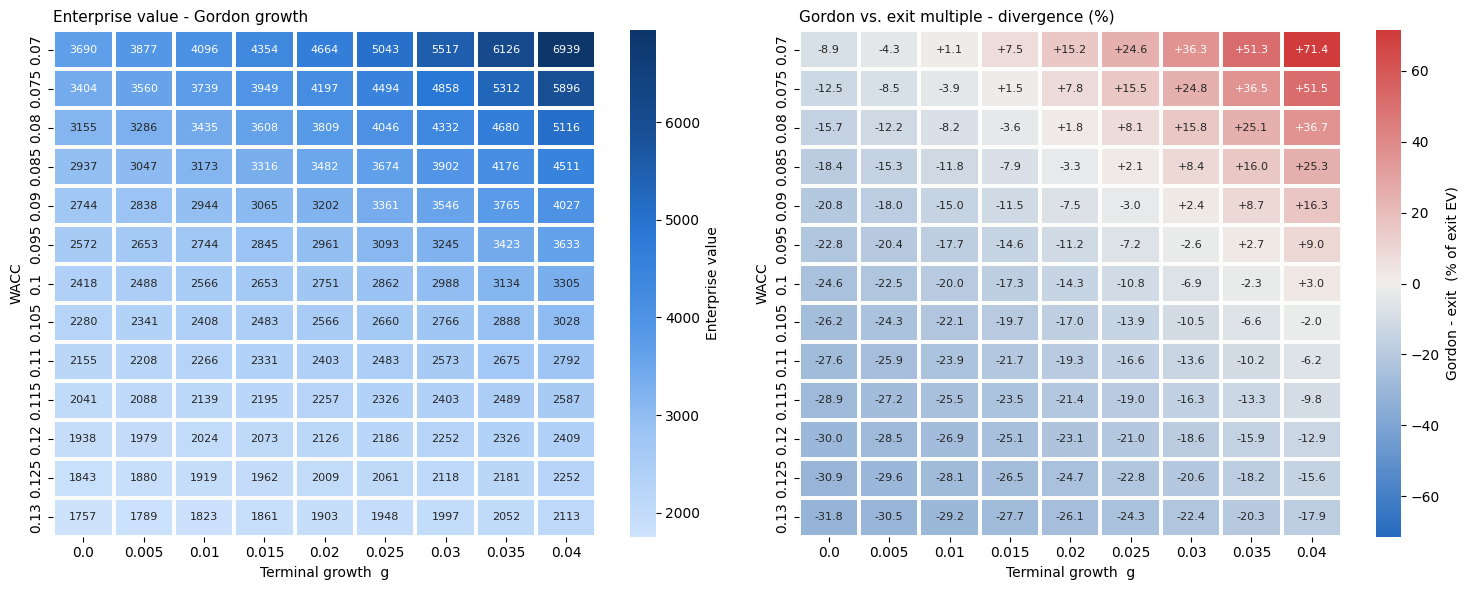

In [3]:
w = np.round(np.arange(0.07, 0.131, 0.005), 4)
g = np.round(np.arange(0.00, 0.041, 0.005), 4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_ev_grid(ev_grid(proj, w, g), ax=ax1)
plot_divergence_grid(divergence_grid(proj, w, g, exit_multiple=8), ax=ax2)
fig.tight_layout()
plt.show()

## 4. The divergence finding

The gray diagonal band on the right is the **agreement locus** - the (WACC, g) pairs where the perpetuity and the exit multiple produce the same value. It *slopes*: at 7% WACC the methods agree near 0.75% terminal growth; at 10% WACC not until ~3.75%. So whether your two 'independent' checks corroborate each other is itself a function of assumptions you picked. And below ~11% WACC in the blue region, Gordon growth never reaches an 8x exit - a signal the multiple is optimistic relative to any plausible perpetuity there. Someone who ran only one method would never see this.

## 5. FCFE and the reconciliation check

FCFE is cash to **equity holders alone**, after debt service; you discount it at the cost of equity and get equity value *directly*. That enables a discipline check: equity-value-computed-directly should match equity-value-backed-out (`enterprise value - net debt`). It reconciles *exactly* with no debt (proof the machinery is right), and the gap under leverage is diagnostic, not a bug.

In [4]:
# With no debt and Re == WACC, FCFE == FCFF and the two equity values match exactly:
no_debt = reconcile_equity(a, wacc=0.10, cost_of_equity=0.10, cost_of_debt=0.06,
                           terminal_growth=0.02, debt_pct=0.0, cash=0.0)
print("no debt gap :", round(no_debt["gap"], 6))

# Levered, with an arbitrary WACC == Re == 11%: a big gap appears...
lev = reconcile_equity(a, 0.11, 0.11, 0.06, 0.02, debt_pct=0.30, cash=0)
print("levered gap :", f'{lev["gap_pct"]:.1f}%  (direct {lev["equity_direct"]:.0f} '
      f'vs indirect {lev["equity_indirect"]:.0f})')

# ...most of which is an INCONSISTENT WACC. Feed a WACC built from the model's
# own capital structure and the gap shrinks sharply:
Re, Rd, debt0 = 0.11, 0.06, 0.30 * a.base_revenue
w_consistent = wacc(lev["equity_direct"], debt0, Re, Rd, 0.25)
fixed = reconcile_equity(a, w_consistent, Re, Rd, 0.02, debt_pct=0.30, cash=0)
print(f"consistent WACC = {w_consistent:.4f}")
print("levered gap :", f'{fixed["gap_pct"]:.1f}%')

no debt gap : 0.0
levered gap : 28.4%  (direct 2701 vs indirect 2103)
consistent WACC = 0.1035
levered gap : 16.5%


The remaining gap is honest: the two methods use different terminal-value constructions (in the FCFE path, net borrowing continues in perpetuity, a perpetual cash inflow to equity), and no simple assumption makes them identical. The reconciliation is not a formula meant to return zero - it is a check that surfaces capital-structure inconsistency. Here it walked a 28% 'something's off' down to a ~16% irreducible modeling choice.

## Where the model is weak

Correct arithmetic is not reliable output. The structural limitations, in order
of importance:

- **Terminal value dominates** (56-80% of EV): most of the answer rests on the
  part of the model you can least defend.
- **The two terminal methods can't both be right**; the divergence grid measures
  the disagreement but does not resolve it.
- **WACC is circular** - it depends on the equity value the DCF is trying to
  produce; this model keeps it exogenous to make that judgment call visible.
- **Ten-year projections are largely fiction past year 3-4**; constant growth and
  margins are conveniences, not forecasts. The back half mainly feeds the
  terminal formula.
- **FCFE reconciliation does not close to zero** under leverage, because the two
  methods embed different terminal debt assumptions.

Read any output as *'under these stated assumptions the value is X, and here is
how hard it leans on the assumptions I trust least.'*